# Plot the trend

In [10]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150  # sharper display in notebook

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ====== journal-ready style constants ======
# keyed by INTERNAL method name (not display label) to avoid lookup failures
METHOD_STYLE = {
    "bissgl": dict(color="#C0392B", linestyle="-", marker="s"),  # red solid
    "bissgl_xi1": dict(color="#C0392B", linestyle="--", marker="s"),  # red dashed
    "imc": dict(color="#2980B9", linestyle="-", marker="o"),  # blue solid
    "sgimc": dict(color="#2980B9", linestyle="--", marker="o"),  # blue dashed
    "drimc": dict(color="#27AE60", linestyle="-", marker="^"),  # green solid
    "nrlmf": dict(color="#8E44AD", linestyle="-", marker="D"),  # purple solid
}

# map internal method names → base display labels
# annotation (e.g. xi=1) is appended by get_method_label via method_filters
METHOD_LABEL = {
    "bissgl": "BVSIMC",
    "bissgl_xi1": "BVSIMC",  # same base; xi annotation comes from method_filters
    "imc": "IMC",
    "sgimc": "SGIMC",
    "drimc": "DRIMC",
    "nrlmf": "NRLMF",
}


def get_method_label(method_name, filters=None):
    """
    Build a display label for a method, appending filtered hyperparams in LaTeX.
    e.g. get_method_label("bissgl", {"xi": 1}) -> "BVSIMC ($\\xi=1$)"
    """
    base = METHOD_LABEL.get(method_name, method_name)
    if not filters:
        return base

    # LaTeX-friendly param names
    LATEX_PARAM = {
        "xi": r"\xi",
        "tilde_lambda0": r"\tilde{\lambda}_0",
        "lambda0": r"\lambda_0",
        "K": "K",
    }
    parts = []
    for k, v in filters.items():
        latex_k = LATEX_PARAM.get(k, k)
        parts.append(f"${latex_k}={v}$")
    return f"{base} ({', '.join(parts)})"


SCORE_COLS = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]
SCORE_LABEL = {
    "aupr": "AUPR",
    "auc": "AUC",
    "f1": "F1 Score",
    "accuracy": "Accuracy",
    "recall": "Recall",
    "specificity": "Specificity",
    "precision": "Precision",
}

# shared rcParams for journal style
RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}


def _plot_one_method(ax, final_df, x_col, metric, label, style):
    """
    Plot a single method curve with error band on a given axes.

    Parameters
    ----------
    ax       : matplotlib Axes
    final_df : pd.DataFrame  output of summarize_method()["final"]
    x_col    : str           column to use as x-axis ('train_size' or 'n_features')
    metric   : str           one of SCORE_COLS
    label    : str           display label for legend
    style    : dict          line/marker style from METHOD_STYLE
    """
    mean_col = f"test_score_{metric}_mean"
    std_col = f"test_score_{metric}_std"

    sub = final_df.sort_values(x_col)
    x = sub[x_col].values
    y = sub[mean_col].values
    ye = sub[std_col].values

    ax.plot(
        x,
        y,
        label=label,
        linewidth=2.0,
        markersize=7,
        markerfacecolor="white",
        markeredgewidth=1.8,
        **style,
    )
    ax.fill_between(
        x,
        y - ye,
        y + ye,
        color=style["color"],
        alpha=0.12,
        linewidth=0,
    )


def plot_vs_train_size(
    results_dict,
    metric="aupr",
    n_features=None,
    method_filters=None,
    ylim=None,
    figsize=(6, 4.5),
    savepath=None,
):
    """
    Plot metric vs training size for each method, optionally filtered to one feature size.

    Parameters
    ----------
    results_dict   : dict  {method_name: final_df}
    metric         : str   score metric to plot (default: 'aupr')
    n_features     : int   if given, restrict to this feature size; otherwise average over all
    method_filters : dict  {method_name: filter_dict} used to build display labels,
                           e.g. {"bissgl": {"xi": 1}}
    ylim           : tuple optional (ymin, ymax)
    figsize        : tuple figure size in inches
    savepath       : str   optional save path (e.g. 'fig.pdf')

    Example
    -------
    plot_vs_train_size(
        {"bissgl": results_b["final"], "imc": results_i["final"]},
        metric="aupr",
        n_features=300,
        method_filters={"bissgl": {"xi": 1}},
    )
    """
    method_filters = method_filters or {}

    with plt.rc_context(RC):
        fig, ax = plt.subplots(figsize=figsize)

        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )

            df = final_df.copy()
            if n_features is not None:
                df = df[df["n_features"] == n_features]
            else:
                mean_col = f"test_score_{metric}_mean"
                std_col = f"test_score_{metric}_std"
                df = df.groupby("train_size", as_index=False).agg(
                    {mean_col: "mean", std_col: "mean"}
                )

            _plot_one_method(ax, df, "train_size", metric, label, style)

        ax.set_xlabel("Training Size", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)

        title_suffix = (
            f" (Number of Features = {n_features})" if n_features is not None else ""
        )
        ax.set_title(
            f"{SCORE_LABEL.get(metric, metric)} vs Training Size{title_suffix}",
            fontsize=13,
            pad=10,
        )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))
        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        ax.legend(fontsize=11, loc="lower right", frameon=False, handlelength=3.0)

        fig.tight_layout()
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()


def plot_vs_n_features(
    results_dict,
    metric="aupr",
    train_size=0.1,
    method_filters=None,
    ylim=None,
    figsize=(6, 4.5),
    savepath=None,
):
    """
    Plot metric vs number of features for each method at a fixed training size.

    Parameters
    ----------
    results_dict   : dict  {method_name: final_df}
    metric         : str   score metric to plot (default: 'aupr')
    train_size     : float fixed training size level to slice (default: 0.1)
    method_filters : dict  {method_name: filter_dict} for display labels
    ylim           : tuple optional (ymin, ymax)
    figsize        : tuple figure size in inches
    savepath       : str   optional save path

    Example
    -------
    plot_vs_n_features(
        {"bissgl": results_b["final"], "imc": results_i["final"]},
        metric="aupr",
        train_size=0.1,
        method_filters={"bissgl": {"xi": 1}},
    )
    """
    method_filters = method_filters or {}

    with plt.rc_context(RC):
        fig, ax = plt.subplots(figsize=figsize)

        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )

            available = final_df["train_size"].unique()
            closest = available[np.argmin(np.abs(available - train_size))]
            df = final_df[final_df["train_size"] == closest].copy()

            _plot_one_method(ax, df, "n_features", metric, label, style)

        ax.set_xlabel("Number of Features", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)
        ax.set_title(
            f"{SCORE_LABEL.get(metric, metric)} vs Number of Features"
            f" (Training Size = {train_size:.0%})",
            fontsize=13,
            pad=10,
        )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        ax.legend(fontsize=11, loc="lower right", frameon=False, handlelength=3.0)

        fig.tight_layout()
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()


def plot_both(
    results_dict,
    metric="aupr",
    n_features_for_train_plot=None,
    train_size_for_feature_plot=0.1,
    method_filters=None,
    ylim=None,
    figsize=(14, 5),
    savepath=None,
):
    """
    Side-by-side figure: left panel = metric vs training size,
    right panel = metric vs number of features.

    Parameters
    ----------
    results_dict                : dict  {method_name: final_df}
    metric                      : str   score metric (default: 'aupr')
    n_features_for_train_plot   : int   optional feature size filter for left panel
    train_size_for_feature_plot : float fixed training size for right panel (default: 0.1)
    method_filters              : dict  {method_name: filter_dict} for display labels
    ylim                        : tuple y-axis limits, default (0.5, 1.01)
    figsize                     : tuple figure size in inches, default (14, 5)
    savepath                    : str   optional save path

    Example
    -------
    plot_both(
        {"bissgl": results_b["final"], "imc": results_i["final"]},
        metric="aupr",
        train_size_for_feature_plot=0.1,
        method_filters={"bissgl": {"xi": 1}},
    )
    """
    method_filters = method_filters or {}
    if ylim is None:
        ylim = (0.5, 1.01)

    with plt.rc_context(RC):
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        # ---- left panel: vs training size ----
        ax = axes[0]
        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )
            df = final_df.copy()
            if n_features_for_train_plot is not None:
                df = df[df["n_features"] == n_features_for_train_plot]
            else:
                mean_col = f"test_score_{metric}_mean"
                std_col = f"test_score_{metric}_std"
                df = df.groupby("train_size", as_index=False).agg(
                    {mean_col: "mean", std_col: "mean"}
                )
            _plot_one_method(ax, df, "train_size", metric, label, style)

        ax.set_xlabel("Training Size", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)
        suffix = (
            f" (Number of Features = {n_features_for_train_plot})"
            if n_features_for_train_plot
            else ""
        )
        ax.set_title(
            f"(A)  {SCORE_LABEL.get(metric, metric)} vs Training Size{suffix}",
            fontsize=13,
            pad=10,
        )
        ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))
        ax.set_ylim(ylim)
        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        # increasing trend → legend safe at lower right
        ax.legend(
            fontsize=10,
            loc="lower right",
            frameon=True,
            handlelength=3.0,
            framealpha=0.7,
            edgecolor="none",
        )

        # ---- right panel: vs number of features ----
        ax = axes[1]
        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )
            available = final_df["train_size"].unique()
            closest = available[
                np.argmin(np.abs(available - train_size_for_feature_plot))
            ]
            df = final_df[final_df["train_size"] == closest].copy()
            _plot_one_method(ax, df, "n_features", metric, label, style)

        ax.set_xlabel("Number of Features", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)
        ax.set_title(
            f"(B)  {SCORE_LABEL.get(metric, metric)} vs Number of Features"
            f" (Training Size = {train_size_for_feature_plot:.0%})",
            fontsize=13,
            pad=10,
        )
        ax.set_ylim(ylim)
        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        # decreasing trend → legend safe at upper right
        ax.legend(
            fontsize=10,
            loc="lower right",
            frameon=True,
            handlelength=3.0,
            framealpha=0.7,
            edgecolor="none",
        )

        fig.tight_layout()
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

In [15]:
# load summaries
final = {
    "bissgl_xi1": summarize_method(PATH_OUTPUT, "bissgl", filters={"xi": 1})["final"],
    "bissgl": summarize_method(PATH_OUTPUT, "bissgl")["final"],
    "imc": summarize_method(PATH_OUTPUT, "imc")["final"],
    "sgimc": summarize_method(PATH_OUTPUT, "sgimc")["final"],
    "drimc": summarize_method(PATH_OUTPUT, "drimc")["final"],
    "nrlmf": summarize_method(PATH_OUTPUT, "nrlmf")["final"],
}

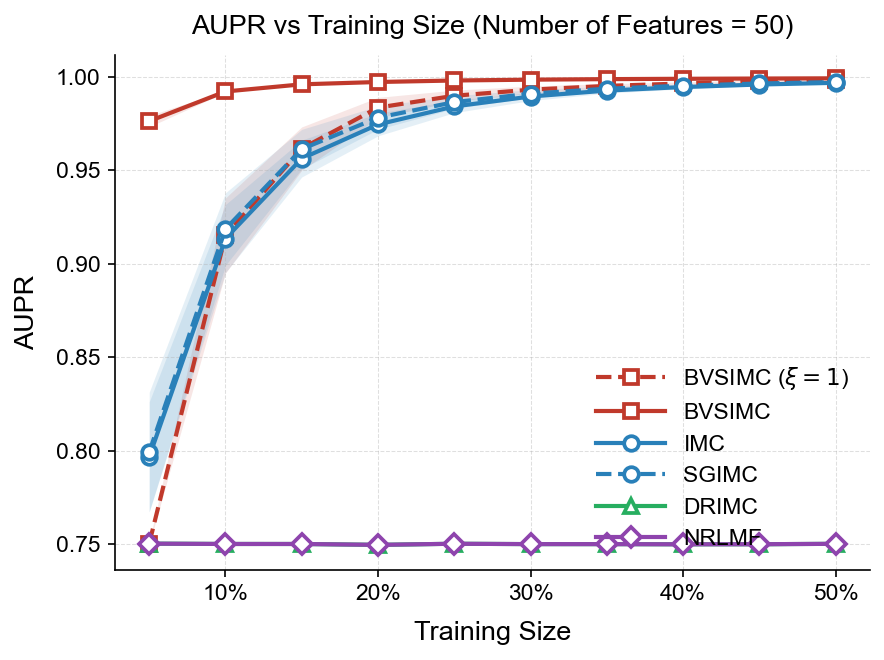

In [16]:
# individual plots
# plot_vs_train_size(final, metric="aupr", n_features=50)
plot_vs_train_size(
    final,
    metric="aupr",
    n_features=50,
    method_filters={"bissgl_xi1": {"xi": 1}},
)

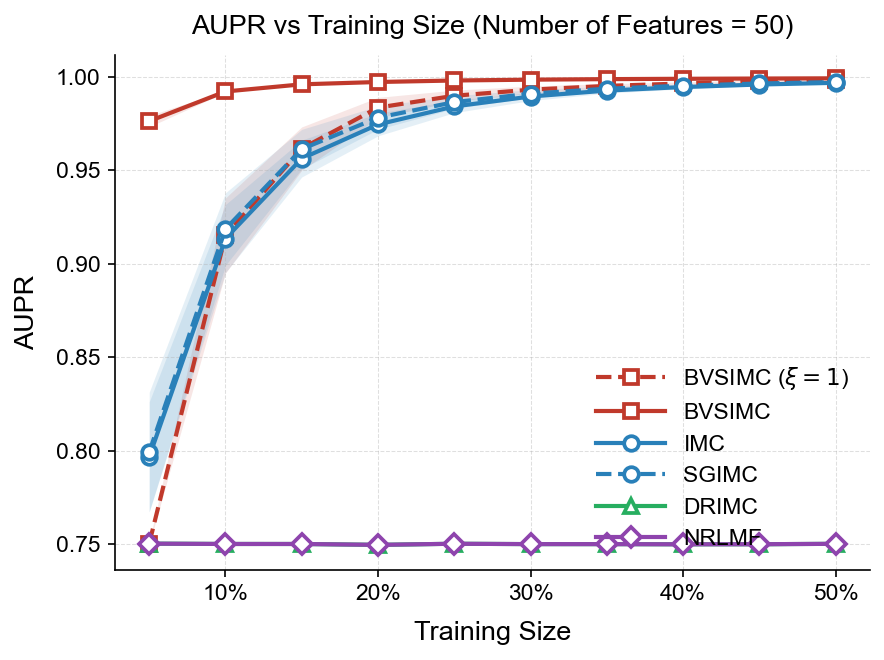

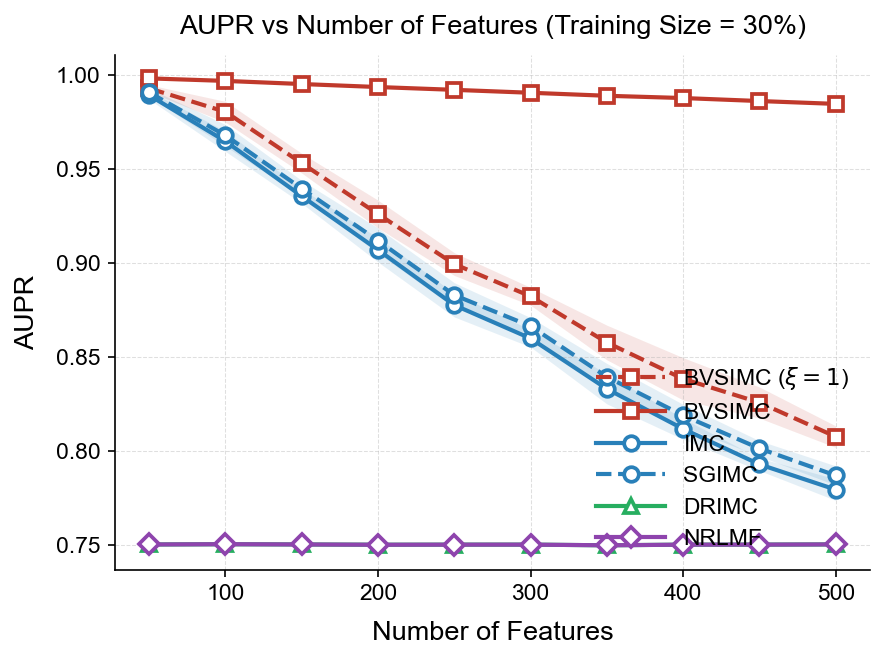

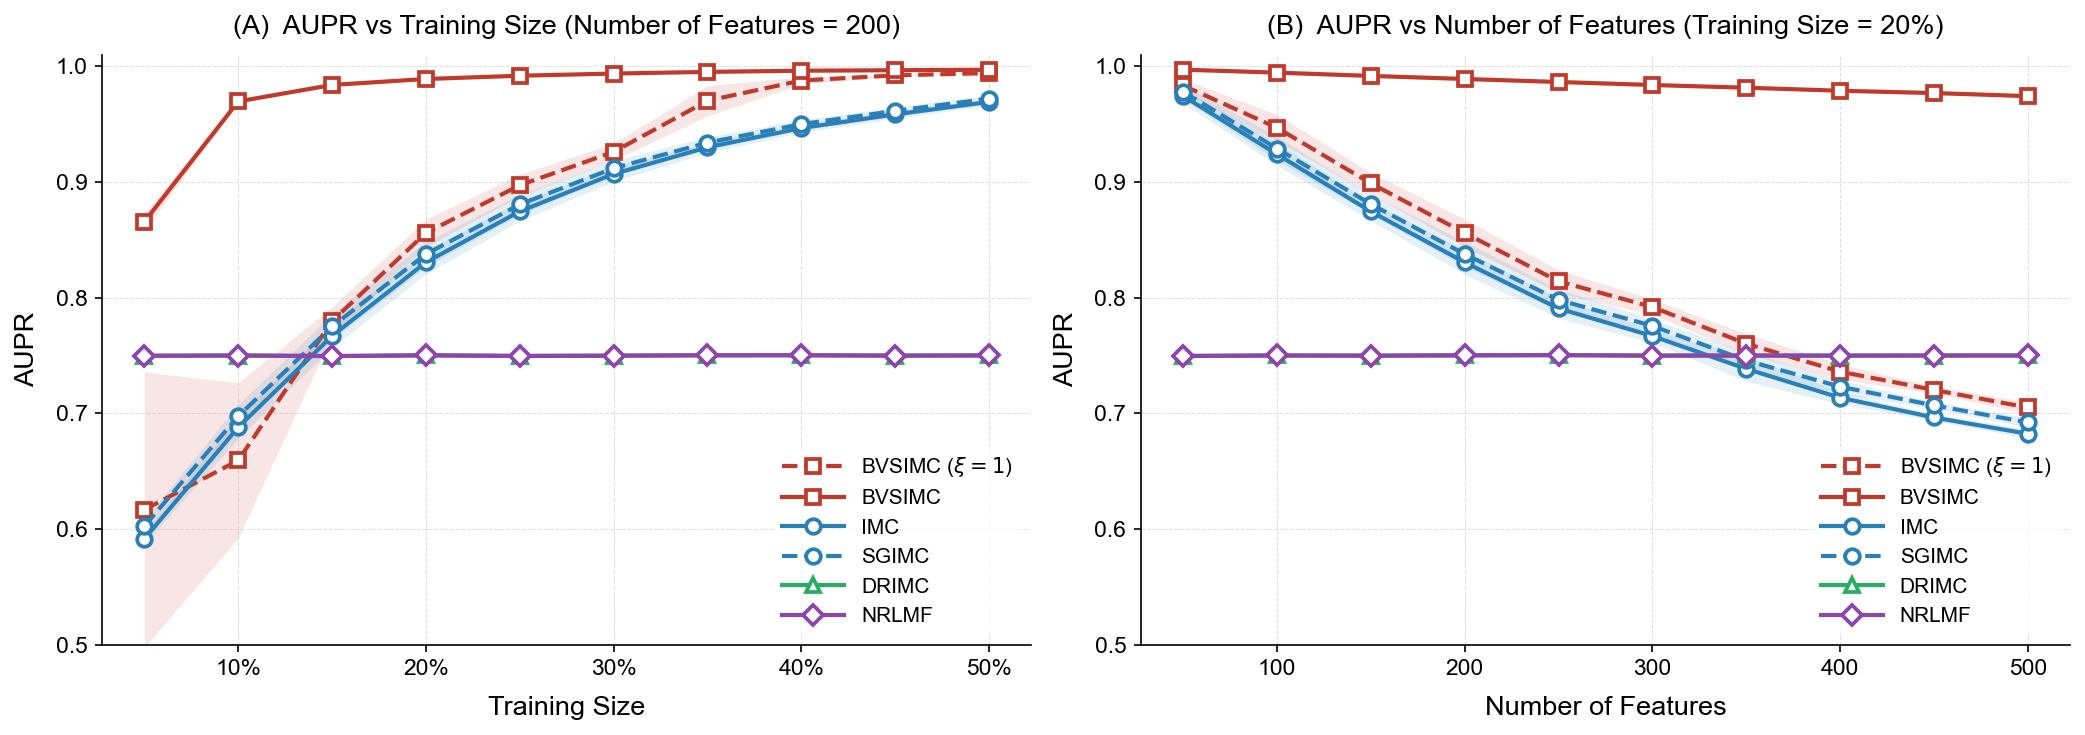

In [23]:
plot_vs_train_size(
    final,
    metric="aupr",
    n_features=50,
    method_filters={"bissgl_xi1": {"xi": 1}},
)

plot_vs_n_features(
    final,
    metric="aupr",
    train_size=0.3,
    method_filters={"bissgl_xi1": {"xi": 1}},
)

plot_both(
    final,
    metric="aupr",
    method_filters={"bissgl_xi1": {"xi": 1}},
    n_features_for_train_plot=200,
    train_size_for_feature_plot=0.2,
)

---

# Summarize the results

In [2]:
"""
Summarize real-application CV results with nested HP selection.

Structure
---------
Raw data: 5 trials × 10 folds × HP combos × 3 inner CV folds

Pipeline (mirrors simulation summarize_results.py)
---------------------------------------------------
Step 1: Average val_score across 3 inner CV folds
        → one row per (trial, fold, HP combo)

Step 2: Select best HP combo per (trial, fold) by val_metric
        → one row per (trial, fold)

Step 3: Retrieve test_score for the best combo per (trial, fold)
        (test_score is identical across inner CV folds for the same combo)
        → one row per (trial, fold)

Step 4: Average test_score across 10 folds per trial
        → one row per trial

Step 5: Mean ± std across 5 trials
        → final summary
"""

import os
import gzip
import pickle
import numpy as np
import pandas as pd


# ====== score vector column names (matches get_metrics return order) ======
SCORE_COLS = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]

# ====== hyperparam columns per method ======
HYPERPARAM_COLS = {
    "bissgl": [
        "xi",
        "eta",
        "tilde_lambda0",
        "tilde_lambda1",
        "lambda0",
        "lambda1",
        "K",
    ],
    "sgimc": ["C_lasso", "C_group", "C_ridge", "rank"],
    "imc": ["C_lasso", "C_group", "C_ridge", "lamb", "rank"],
    "drimc": ["lamU", "lamV", "cc", "iterpara", "numLat"],
    "nrlmf": [
        "cfix",
        "K1",
        "K2",
        "num_factors",
        "lambda_d",
        "lambda_t",
        "alpha",
        "beta",
        "theta",
        "max_iter",
    ],
}


# ====== load results — single stacked file or multiple task files ======
def load_results(output_dir, method_name):
    """
    Load results for a given method.

    Handles two layouts:
      1. Single stacked file:  results_<method>.gz       (from local runs)
      2. Multiple task files:  results_<method>_task*.gz  (from HPC runs)

    Returns
    -------
    pd.DataFrame  one row per (trial, fold, HP combo, inner CV fold)
    """
    single_file = os.path.join(output_dir, f"results_{method_name}.gz")
    if os.path.exists(single_file):
        with gzip.open(single_file, "rb") as fin:
            rows = pickle.load(fin)
    else:
        prefix = f"results_{method_name}_task"
        files = sorted(
            f
            for f in os.listdir(output_dir)
            if f.startswith(prefix) and f.endswith(".gz")
        )
        if not files:
            raise FileNotFoundError(
                f"No file 'results_{method_name}.gz' and no task files "
                f"matching '{prefix}*.gz' found in {output_dir}"
            )
        rows = []
        for fname in files:
            with gzip.open(os.path.join(output_dir, fname), "rb") as fin:
                rows.extend(pickle.load(fin))

    df = pd.DataFrame(rows)
    df["val_score"] = df["val_score"].apply(np.asarray)
    df["test_score"] = df["test_score"].apply(np.asarray)
    return df


# ====== expand score vector into named columns ======
def expand_scores(df, col, names=SCORE_COLS):
    """
    Expand a column of score vectors into individual named columns.
    e.g. 'val_score' → 'val_score_aupr', 'val_score_auc', ...
    """
    expanded = pd.DataFrame(
        np.stack(df[col].values),
        index=df.index,
        columns=[f"{col}_{n}" for n in names],
    )
    return expanded


# ====== main summarization pipeline ======
def summarize_results(
    df, hyperparam_cols, val_metric="aupr", n_orig_U=None, n_orig_V=None
):
    """
    Summarize real-application CV results with nested HP selection.

    Pipeline  (analogous to simulation summarize_results)
    --------
    1. Average val_score across 3 inner CV folds
       → per (trial, fold, HP combo)

    2. Select best HP combo per (trial, fold) by val_metric
       → per (trial, fold)

    3. Retrieve test_score for the best combo
       (test_score is identical across inner CV folds for the same HP combo,
        so we merge on (trial, fold, HPs) and take first row per (trial, fold))

    4. Average test_score across 10 folds per trial
       → per trial

    5. Mean ± std across 5 trials
       → single-row final summary

    Parameters
    ----------
    df             : pd.DataFrame  raw results from load_results()
    hyperparam_cols: list[str]     HP column names for this method
    val_metric     : str           score metric for HP selection (default: 'aupr')
    n_orig_U       : int or None   number of original drug-side features (before
                                   identity augmentation); if given, d1_orig is
                                   recomputed excluding augmented indices
    n_orig_V       : int or None   number of original target-side features

    Returns
    -------
    dict with keys:
        'raw'            : original DataFrame (after any filters)
        'val_avg'        : Step 1 output
        'best_params'    : Step 2 output
        'test_per_fold'  : Step 3 output — test scores for best HP per (trial, fold)
        'test_per_trial' : Step 4 output — averaged across folds per trial
        'final'          : Step 5 output — mean ± std across trials
    """
    fold_cols = ["trial", "fold"]
    group_cols = fold_cols + hyperparam_cols

    # ------------------------------------------------------------------
    # Step 1: average val_score across inner CV folds
    #         group by (trial, fold, HP combo), average over cv=0,1,2
    # ------------------------------------------------------------------
    val_avg = df.groupby(group_cols, as_index=False).agg(
        val_score=("val_score", lambda x: np.mean(np.stack(x), axis=0)),
        val_d1=("val_d1", "mean"),
        val_d2=("val_d2", "mean"),
        n_inner_cv=("cv", "count"),  # diagnostic: should be 3
    )

    # expand val_score vector into named columns
    val_avg = pd.concat(
        [val_avg.drop(columns=["val_score"]), expand_scores(val_avg, "val_score")],
        axis=1,
    )
    val_metric_col = f"val_score_{val_metric}"

    # ------------------------------------------------------------------
    # Step 2: select best HP combo per (trial, fold)
    #         pick the HP combo with highest val_metric per outer fold
    # ------------------------------------------------------------------
    best_idx = val_avg.groupby(fold_cols)[val_metric_col].idxmax()
    best_params = val_avg.loc[
        best_idx, fold_cols + hyperparam_cols + [val_metric_col, "n_inner_cv"]
    ].reset_index(drop=True)

    # ------------------------------------------------------------------
    # Step 3: retrieve test_score for the best combo per (trial, fold)
    #         test_score is the same across inner CV folds for the same
    #         (trial, fold, HP) combo, so merge and deduplicate
    # ------------------------------------------------------------------
    df_best = df.merge(
        best_params[fold_cols + hyperparam_cols],
        on=fold_cols + hyperparam_cols,
        how="inner",
    )

    # detect available columns (feature selection indices may or may not exist)
    base_cols = fold_cols + hyperparam_cols + ["test_score", "test_d1", "test_d2"]
    sel_cols_available = [
        c
        for c in ["test_sel_W", "test_sel_H", "test_sel_A", "test_sel_B"]
        if c in df_best.columns
    ]
    keep_cols = base_cols + sel_cols_available

    # deduplicate: one row per (trial, fold)
    test_per_fold = df_best.groupby(fold_cols, as_index=False).first()[keep_cols]

    # expand test_score vector into named columns
    test_per_fold = pd.concat(
        [
            test_per_fold.drop(columns=["test_score"]),
            expand_scores(test_per_fold, "test_score"),
        ],
        axis=1,
    )

    # ------------------------------------------------------------------
    # Step 3b: recompute d1/d2 excluding augmented identity features
    #          (only when n_orig_U / n_orig_V is provided and sel dicts exist)
    # ------------------------------------------------------------------
    # d1 = drug-side: test_sel_A (BiSSGL) or test_sel_W (SGIMC)
    d1_sel_col = next(
        (c for c in ["test_sel_A", "test_sel_W"] if c in test_per_fold.columns), None
    )
    # d2 = target-side: test_sel_B (BiSSGL) or test_sel_H (SGIMC)
    d2_sel_col = next(
        (c for c in ["test_sel_B", "test_sel_H"] if c in test_per_fold.columns), None
    )

    if n_orig_U is not None and d1_sel_col is not None:
        test_per_fold["test_d1_orig"] = test_per_fold[d1_sel_col].apply(
            lambda d: sum(
                1 for k in (d.keys() if isinstance(d, dict) else d) if int(k) < n_orig_U
            )
        )
    if n_orig_V is not None and d2_sel_col is not None:
        test_per_fold["test_d2_orig"] = test_per_fold[d2_sel_col].apply(
            lambda d: sum(
                1 for k in (d.keys() if isinstance(d, dict) else d) if int(k) < n_orig_V
            )
        )

    # ------------------------------------------------------------------
    # Step 4: average test_score across 10 folds per trial
    # ------------------------------------------------------------------
    test_score_cols = [f"test_score_{n}" for n in SCORE_COLS]
    has_d1_orig = "test_d1_orig" in test_per_fold.columns
    has_d2_orig = "test_d2_orig" in test_per_fold.columns

    agg_dict = {
        **{c: (c, "mean") for c in test_score_cols},
        "test_d1_mean": ("test_d1", "mean"),
        "test_d2_mean": ("test_d2", "mean"),
        "n_folds": ("fold", "count"),
    }
    if has_d1_orig:
        agg_dict["test_d1_orig_mean"] = ("test_d1_orig", "mean")
    if has_d2_orig:
        agg_dict["test_d2_orig_mean"] = ("test_d2_orig", "mean")

    test_per_trial = test_per_fold.groupby("trial", as_index=False).agg(**agg_dict)

    # ------------------------------------------------------------------
    # Step 5: mean ± std across 5 trials
    # ------------------------------------------------------------------
    final = {}
    for c in test_score_cols:
        vals = test_per_trial[c].values
        final[f"{c}_mean"] = vals.mean()
        final[f"{c}_std"] = vals.std(ddof=1)
    final["test_d1_mean"] = test_per_trial["test_d1_mean"].mean()
    final["test_d2_mean"] = test_per_trial["test_d2_mean"].mean()
    if has_d1_orig:
        final["test_d1_orig_mean"] = test_per_trial["test_d1_orig_mean"].mean()
    if has_d2_orig:
        final["test_d2_orig_mean"] = test_per_trial["test_d2_orig_mean"].mean()
    final["n_trials"] = len(test_per_trial)
    final["n_folds_per_trial"] = int(test_per_trial["n_folds"].iloc[0])
    final = pd.DataFrame([final])

    return {
        "raw": df,
        "val_avg": val_avg,
        "best_params": best_params,
        "test_per_fold": test_per_fold,
        "test_per_trial": test_per_trial,
        "final": final,
    }


def summarize_results_pooled(
    df, hyperparam_cols, val_metric="aupr", n_orig_U=None, n_orig_V=None
):
    """
    Alternative summarization: pool all 50 folds directly.

    Same as summarize_results Steps 1-3 (pick best HP per fold by val_metric,
    retrieve test scores), but then average across ALL 50 folds directly
    instead of grouping by trial first.

    This allows each (trial, fold) to use a different HP combo, and reports
    mean ± std across all 50 folds. Useful to compare with the per-trial
    approach: if results are similar, HP selection is stable.

    Returns
    -------
    dict with same keys as summarize_results, except:
        'test_per_trial' is absent
        'final'          is mean ± std across all 50 folds (not 5 trials)
    """
    # Steps 1-3 are identical — reuse summarize_results
    results = summarize_results(
        df, hyperparam_cols, val_metric=val_metric, n_orig_U=n_orig_U, n_orig_V=n_orig_V
    )

    test_per_fold = results["test_per_fold"]
    test_score_cols = [f"test_score_{n}" for n in SCORE_COLS]

    # ------------------------------------------------------------------
    # Pooled averaging: mean ± std across all N folds directly
    # ------------------------------------------------------------------
    n_folds_total = len(test_per_fold)
    final = {}
    for c in test_score_cols:
        vals = test_per_fold[c].values
        final[f"{c}_mean"] = vals.mean()
        final[f"{c}_std"] = vals.std(ddof=1)
    final["test_d1_mean"] = test_per_fold["test_d1"].mean()
    final["test_d2_mean"] = test_per_fold["test_d2"].mean()
    if "test_d1_orig" in test_per_fold.columns:
        final["test_d1_orig_mean"] = test_per_fold["test_d1_orig"].mean()
    if "test_d2_orig" in test_per_fold.columns:
        final["test_d2_orig_mean"] = test_per_fold["test_d2_orig"].mean()
    final["n_folds_total"] = n_folds_total
    final["averaging"] = "pooled"
    final = pd.DataFrame([final])

    return {
        "raw": results["raw"],
        "val_avg": results["val_avg"],
        "best_params": results["best_params"],
        "test_per_fold": test_per_fold,
        "final": final,
    }


# ====== convenience wrapper per method ======
def summarize_method(
    output_dir,
    method_name,
    val_metric="aupr",
    filters=None,
    pooled=False,
    n_orig_U=None,
    n_orig_V=None,
):
    """
    Load results and summarize for a given method in one call.

    Parameters
    ----------
    output_dir  : str   path to result files
    method_name : str   one of 'bissgl', 'sgimc', 'imc', 'drimc', 'nrlmf'
    val_metric  : str   score metric for HP selection (default: 'aupr')
    filters     : dict  optional column filters, e.g. {"xi": 1}
    pooled      : bool  if True, average across all 50 folds directly
                        (HP can vary per fold); if False (default),
                        average within each trial first, then across trials.
    n_orig_U    : int   original drug-side feature count (before identity
                        augmentation); d1 summary will exclude augmented features
    n_orig_V    : int   original target-side feature count

    Example
    -------
    # Standard with original-only feature counts
    res = summarize_method(PATH, "bissgl", filters={"xi": 1},
                           n_orig_U=9000, n_orig_V=33)
    """
    hyperparam_cols = HYPERPARAM_COLS[method_name]
    df = load_results(output_dir, method_name)

    if filters is not None:
        for col, val in filters.items():
            df = df[df[col] == val]
        df = df.reset_index(drop=True)

    if pooled:
        return summarize_results_pooled(
            df,
            hyperparam_cols,
            val_metric=val_metric,
            n_orig_U=n_orig_U,
            n_orig_V=n_orig_V,
        )
    else:
        return summarize_results(
            df,
            hyperparam_cols,
            val_metric=val_metric,
            n_orig_U=n_orig_U,
            n_orig_V=n_orig_V,
        )


# ====== diagnostics ======
def check_completeness(results, method_name, expected_trials=5, expected_folds=10):
    """
    Print diagnostic info to verify results are complete.

    Checks:
    - Number of raw rows
    - Number of (trial, fold) pairs with results
    - Number of inner CV folds per combo
    - Number of HP combos per fold
    """
    df = results["raw"]
    tpf = results["test_per_fold"]

    n_raw = len(df)
    n_outer_folds = len(tpf)
    expected_outer = expected_trials * expected_folds

    # count unique HP combos
    hyperparam_cols = HYPERPARAM_COLS[method_name]
    hp_combos = df.groupby(hyperparam_cols).ngroups

    # inner CV fold count per combo
    inner_counts = df.groupby(["trial", "fold"] + hyperparam_cols)["cv"].count()

    print(f"\n{'='*60}")
    print(f"  Diagnostics: {method_name}")
    print(f"{'='*60}")
    print(f"  Raw result rows:             {n_raw}")
    print(f"  HP combos:                   {hp_combos}")
    print(f"  Expected inner CV per combo:  3")
    print(f"  Actual inner CV (min/max):    {inner_counts.min()}/{inner_counts.max()}")
    print(f"  Outer folds with results:    {n_outer_folds} / {expected_outer} expected")

    # check for missing (trial, fold) pairs
    all_pairs = set(
        (t, f) for t in range(expected_trials) for f in range(expected_folds)
    )
    present_pairs = set(zip(tpf["trial"], tpf["fold"]))
    missing = all_pairs - present_pairs
    if missing:
        print(f"  *** MISSING folds: {sorted(missing)}")
    else:
        print(f"  All {expected_outer} outer folds present ✓")
    print(f"{'='*60}\n")


# ====== pretty-print single method ======
def print_summary(results, method_label="Method"):
    """Print a compact summary of the final results (handles both averaging modes)."""
    final = results["final"]

    # detect averaging mode
    if "averaging" in final.columns and final["averaging"].iloc[0] == "pooled":
        n = int(final["n_folds_total"].iloc[0])
        subtitle = f"pooled across {n} folds (HP varies per fold)"
    else:
        n_trials = int(final["n_trials"].iloc[0])
        n_folds = int(final["n_folds_per_trial"].iloc[0])
        subtitle = f"{n_trials} trials × {n_folds}-fold CV"

    print(f"\n{'='*60}")
    print(f"  {method_label}  —  {subtitle}")
    print(f"{'='*60}")
    for metric in SCORE_COLS:
        m = final[f"test_score_{metric}_mean"].iloc[0]
        s = final[f"test_score_{metric}_std"].iloc[0]
        print(f"  {metric:>12s}:  {m:.4f} ± {s:.4f}")

    # d1/d2: show original-only count if available, otherwise total
    has_d1_orig = "test_d1_orig_mean" in final.columns
    has_d2_orig = "test_d2_orig_mean" in final.columns

    d1_total = final["test_d1_mean"].iloc[0]
    d2_total = final["test_d2_mean"].iloc[0]

    if has_d1_orig:
        d1_orig = final["test_d1_orig_mean"].iloc[0]
        print(
            f"  {'d1 (orig)':>12s}:  {d1_orig:.1f}  (total incl. augmented: {d1_total:.1f})"
        )
    else:
        print(f"  {'d1 (mean)':>12s}:  {d1_total:.1f}")

    if has_d2_orig:
        d2_orig = final["test_d2_orig_mean"].iloc[0]
        print(
            f"  {'d2 (orig)':>12s}:  {d2_orig:.1f}  (total incl. augmented: {d2_total:.1f})"
        )
    else:
        print(f"  {'d2 (mean)':>12s}:  {d2_total:.1f}")

    print(f"{'='*60}\n")


# ====== pretty-print comparison across methods ======
def print_all_summaries(all_results):
    """
    Print a comparison table across all methods.

    Parameters
    ----------
    all_results : dict  {method_label: results_dict}
                  e.g. {"BVSIMC": results_bissgl, "SGIMC": results_sgimc, ...}

    Example
    -------
    all_results = {
        "BVSIMC":  summarize_method(PATH, "bissgl", filters={"xi": 1}),
        "SGIMC":   summarize_method(PATH, "sgimc"),
        "IMC":     summarize_method(PATH, "imc"),
        "DRIMC":   summarize_method(PATH, "drimc"),
        "NRLMF":   summarize_method(PATH, "nrlmf"),
    }
    print_all_summaries(all_results)
    """
    methods = list(all_results.keys())
    col_w = max(16, max(len(m) for m in methods) + 2)

    # header
    print(f"\n{'='*(14 + col_w * len(methods) + 2 * len(methods))}")
    print(f"  {'Metric':<14s}", end="")
    for m in methods:
        print(f"  {m:>{col_w}s}", end="")
    print()
    print(f"{'='*(14 + col_w * len(methods) + 2 * len(methods))}")

    for metric in SCORE_COLS:
        print(f"  {metric:<14s}", end="")
        for m in methods:
            final = all_results[m]["final"]
            mean = final[f"test_score_{metric}_mean"].iloc[0]
            std = final[f"test_score_{metric}_std"].iloc[0]
            print(f"  {mean:.5f}±{std:.5f}", end="")
        print()

    # d1, d2
    for d_metric, d_label in [
        ("test_d1_mean", "d1 (mean)"),
        ("test_d2_mean", "d2 (mean)"),
    ]:
        print(f"  {d_label:<14s}", end="")
        for m in methods:
            val = all_results[m]["final"][d_metric].iloc[0]
            print(f"  {val:>{col_w}.1f}", end="")
        print()

    print(f"{'='*(14 + col_w * len(methods) + 2 * len(methods))}\n")


# ====== feature selection frequency analysis ======
def get_feature_frequency(results, sel_col, feature_names=None, n_orig=None):
    """
    Count selection frequency and aggregate importance (L2 norm) across folds.

    The sel_col column should contain dicts of {feature_idx: L2_row_norm}.
    Only works for methods that store feature selection info
    (BiSSGL: test_sel_A / test_sel_B,  SGIMC: test_sel_W / test_sel_H).

    Parameters
    ----------
    results       : dict   output of summarize_method()
    sel_col       : str    column name, e.g. 'test_sel_A' or 'test_sel_W'
    feature_names : list   optional feature names to map indices to
    n_orig        : int    if given, exclude features with index >= n_orig
                           (i.e. the identity-augmented columns)

    Returns
    -------
    pd.DataFrame  sorted by frequency (descending), with columns:
        feature_idx   : int     0-based feature index
        feature_name  : str     (if feature_names provided)
        count         : int     number of folds where this feature was selected
        frequency     : float   count / total number of folds
        norm_mean     : float   mean L2 row norm across folds where selected
        norm_std      : float   std of L2 row norm across those folds

    Example
    -------
    # n_orig_U = 9000 original features, augmented with 6000-dim identity
    freq_A = get_feature_frequency(results, "test_sel_A", n_orig=9000)
    # → only features 0..8999 are reported; identity columns 9000+ excluded
    """
    tpf = results["test_per_fold"]

    if sel_col not in tpf.columns:
        available = [c for c in tpf.columns if c.startswith("test_sel_")]
        raise KeyError(
            f"Column '{sel_col}' not found in test_per_fold. "
            f"Available selection columns: {available}"
        )

    n_folds = len(tpf)

    # collect all norms per feature index
    from collections import defaultdict

    norms_by_idx = defaultdict(list)
    for sel_dict in tpf[sel_col]:
        if isinstance(sel_dict, dict):
            for idx, norm in sel_dict.items():
                idx = int(idx)
                if n_orig is not None and idx >= n_orig:
                    continue  # skip augmented identity features
                norms_by_idx[idx].append(float(norm))
        else:
            # backward compatibility: plain list of indices (no norms)
            for idx in sel_dict:
                idx = int(idx)
                if n_orig is not None and idx >= n_orig:
                    continue
                norms_by_idx[idx].append(np.nan)

    # build output DataFrame
    rows = []
    for feat_idx in sorted(norms_by_idx.keys()):
        norms = norms_by_idx[feat_idx]
        row = {
            "feature_idx": feat_idx,
            "count": len(norms),
            "frequency": len(norms) / n_folds,
            "norm_mean": float(np.nanmean(norms)),
            "norm_std": float(np.nanstd(norms, ddof=1)) if len(norms) > 1 else 0.0,
        }
        if feature_names is not None:
            row["feature_name"] = feature_names[feat_idx]
        rows.append(row)

    freq_df = pd.DataFrame(rows)

    if len(freq_df) == 0:
        return freq_df

    # order columns nicely
    col_order = ["feature_idx"]
    if feature_names is not None:
        col_order.append("feature_name")
    col_order.extend(["count", "frequency", "norm_mean", "norm_std"])
    freq_df = (
        freq_df[col_order].sort_values("count", ascending=False).reset_index(drop=True)
    )

    return freq_df


def print_top_features(freq_df, top_n=20, label="Features"):
    """Print the top-N most frequently selected features with importance."""
    n_total = (
        int(round(freq_df["count"].iloc[0] / freq_df["frequency"].iloc[0]))
        if len(freq_df) > 0
        else 0
    )
    print(f"\n{'='*70}")
    print(f"  Top {top_n} {label}  (out of {n_total} outer folds)")
    print(f"{'='*70}")
    has_name = "feature_name" in freq_df.columns
    has_norm = "norm_mean" in freq_df.columns and not freq_df["norm_mean"].isna().all()
    for _, row in freq_df.head(top_n).iterrows():
        name_str = f"  {row['feature_name']}" if has_name else ""
        norm_str = (
            f"  ||r||={row['norm_mean']:.3f}±{row['norm_std']:.3f}" if has_norm else ""
        )
        print(
            f"  idx {row['feature_idx']:>4d}{name_str:30s}  "
            f"count={row['count']:>3d}  freq={row['frequency']:.0%}{norm_str}"
        )
    print(f"{'='*70}\n")

In [33]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")
PATH_OUTPUT = os.path.join(
    PATH_ROOT, "outputs/results/realAnalysis/cdataset/fold_cv/origin"
)
PATH_OUTPUT_COMB = os.path.join(
    PATH_ROOT, "outputs/results/realAnalysis/cdataset/fold_cv/comb"
)
PATH_OUTPUT_COMB_XI = os.path.join(
    PATH_ROOT, "outputs/results/realAnalysis/cdataset/fold_cv/comb/xi"
)
PATH_OUTPUT_ORIGIN = os.path.join(
    PATH_ROOT, "outputs/results/realAnalysis/cdataset/fold_cv/origin"
)

# summarize each method
res_b = summarize_method(PATH_OUTPUT_COMB_XI, "bissgl", filters={"xi": 1})
res_s = summarize_method(PATH_OUTPUT_COMB, "sgimc")
res_i = summarize_method(PATH_OUTPUT_COMB, "imc")
res_d = summarize_method(PATH_OUTPUT, "drimc")
res_n = summarize_method(PATH_OUTPUT, "nrlmf")

# check completeness
for name, res in [
    ("bissgl", res_b),
    ("sgimc", res_s),
    ("imc", res_i),
    ("drimc", res_d),
    ("nrlmf", res_n),
]:
    check_completeness(res, name)

# side-by-side comparison
print_all_summaries(
    {
        "BVSIMC": res_b,
        "SGIMC": res_s,
        "IMC": res_i,
        "DRIMC": res_d,
        "NRLMF": res_n,
    }
)


  Diagnostics: bissgl
  Raw result rows:             450
  HP combos:                   3
  Expected inner CV per combo:  3
  Actual inner CV (min/max):    3/3
  Outer folds with results:    50 / 50 expected
  All 50 outer folds present ✓


  Diagnostics: sgimc
  Raw result rows:             513
  HP combos:                   13
  Expected inner CV per combo:  3
  Actual inner CV (min/max):    3/6
  Outer folds with results:    27 / 50 expected
  *** MISSING folds: [(0, 0), (0, 1), (0, 2), (0, 4), (0, 5), (1, 1), (1, 7), (1, 9), (2, 2), (2, 4), (2, 6), (2, 8), (3, 0), (3, 2), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (4, 3), (4, 6), (4, 8), (4, 9)]


  Diagnostics: imc
  Raw result rows:             450
  HP combos:                   3
  Expected inner CV per combo:  3
  Actual inner CV (min/max):    3/3
  Outer folds with results:    50 / 50 expected
  All 50 outer folds present ✓


  Diagnostics: drimc
  Raw result rows:             2700
  HP combos:                   18
  Expected in

In [34]:
res_b['best_params']

,trial,fold,xi,eta,tilde_lambda0,tilde_lambda1,lambda0,lambda1,K,val_score_aupr,n_inner_cv
0,0,0,1,5.000000e-07,15,1,15,1,50,0.179938,3
1,0,1,1,5.000000e-07,15,1,15,1,50,0.181269,3
2,0,2,1,5.000000e-07,15,1,15,1,50,0.187852,3
3,0,3,1,5.000000e-07,15,1,15,1,50,0.178706,3
4,0,4,1,5.000000e-07,15,1,15,1,50,0.184249,3
5,0,5,1,5.000000e-07,15,1,15,1,50,0.170418,3
6,0,6,1,5.000000e-07,15,1,15,1,50,0.174756,3
7,0,7,1,5.000000e-07,15,1,15,1,50,0.175757,3
8,0,8,1,5.000000e-07,15,1,15,1,50,0.184058,3
9,0,9,1,5.000000e-07,15,1,15,1,50,0.171208,3


For DRIMC, Based on the histogram of the selected best hyper-parameters, we found the performance is less sensitive to the number of column size, as the across the total trails, the histogram looks like a uniform distribution, with the grid of 50, 100 and 200, the counts of being the best are 18, 17 and 15. As for the lamU, and lamV, we tuned the lamU and lamV through a grid search of 1, 2, 4, which has the counts as 20, 26, 4 and 15, 20, 15. This also suggested less sensitive to the choice of lamV in the performance. 

For DRIMC, the best one takes xi to be 1, and the increase of xi will even decrease the performance, when it is incorportated in such a way.


For NRLMF, earlier we thought it will be similar to DRIMC, but instead, the increase of xi can be helpful, but the parameter selected as the best with counts 27 for 5 and 23 for 10, which may suggest to set xi greater than 1 will be benefical. 

In [34]:
res_b['raw']

,trial,fold,xi,eta,tilde_lambda0,tilde_lambda1,lambda0,lambda1,K,cv,val_score,val_d1,val_d2,test_score,test_d1,test_d2,test_sel_A,test_sel_B
0,0,0,1000,1.000000e-07,10,1,10,1,50,0,"[0.16075787830791455, 0.8935021605471936, 0.16...",2546,1206,"[0.18866264269620925, 0.9057685997783034, 0.18...",2546,1206,"{0: 0.04150988112759416, 1: 1.0681175092380948...","{0: 8.416118978569127, 1: 4.6392904057085165, ..."
1,0,0,1000,1.000000e-07,10,1,10,1,50,1,"[0.1633504629654086, 0.8778126427858438, 0.165...",2546,1206,"[0.18866264269620925, 0.9057685997783034, 0.18...",2546,1206,"{0: 0.04150988112759416, 1: 1.0681175092380948...","{0: 8.416118978569127, 1: 4.6392904057085165, ..."
2,0,0,1000,1.000000e-07,10,1,10,1,50,2,"[0.17329011137975078, 0.8963878976340706, 0.16...",2546,1206,"[0.18866264269620925, 0.9057685997783034, 0.18...",2546,1206,"{0: 0.04150988112759416, 1: 1.0681175092380948...","{0: 8.416118978569127, 1: 4.6392904057085165, ..."
3,0,0,1000,1.000000e-07,100,1,100,1,50,0,"[0.27888885487842763, 0.7574324576632492, 0.04...",2546,1206,"[0.29620916506957073, 0.772672581434331, 0.054...",2546,1206,"{0: 83101196768129.83, 1: 166962985127161.0, 2...","{0: 255361421938089.28, 1: 178727112231010.8, ..."
4,0,0,1000,1.000000e-07,100,1,100,1,50,1,"[0.2664056542965912, 0.7455592209688553, 0.041...",2546,1206,"[0.29620916506957073, 0.772672581434331, 0.054...",2546,1206,"{0: 83101196768129.83, 1: 166962985127161.0, 2...","{0: 255361421938089.28, 1: 178727112231010.8, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,3,2,1000,1.000000e-07,1000,1,1000,1,50,1,"[0.14171987284770626, 0.8960197476691126, 0.13...",2546,1206,"[0.02992597405135839, 0.8036301704949165, 0.03...",1956,976,"{0: 0.9301918394684179, 1: 2.0378441572426187,...","{0: 3.506068753553127, 1: 2.6798349000380886, ..."
422,3,2,1000,1.000000e-07,1000,1,1000,1,50,2,"[0.13107326679541143, 0.898881267187334, 0.129...",2546,1206,"[0.02992597405135839, 0.8036301704949165, 0.03...",1956,976,"{0: 0.9301918394684179, 1: 2.0378441572426187,...","{0: 3.506068753553127, 1: 2.6798349000380886, ..."
423,3,3,1000,1.000000e-07,10,1,10,1,50,0,"[0.16114544385270702, 0.9134772222293573, 0.16...",2546,1206,"[0.15606978740865624, 0.9010637311690941, 0.20...",2546,1206,"{0: 0.03226812783657038, 1: 1.4058381366522323...","{0: 8.204726098474227, 1: 4.8868415915582615, ..."
424,3,3,1000,1.000000e-07,10,1,10,1,50,1,"[0.17379300739614367, 0.90508696550365, 0.1818...",2546,1206,"[0.15606978740865624, 0.9010637311690941, 0.20...",2546,1206,"{0: 0.03226812783657038, 1: 1.4058381366522323...","{0: 8.204726098474227, 1: 4.8868415915582615, ..."


In [22]:
# Standard: 5-trial summary
res = summarize_method(PATH_OUTPUT_COMB_XI, "bissgl")
print_summary(res, "BVSIMC (per-trial)")

# Pooled: 50-fold summary, HP varies per fold
res_p = summarize_method(PATH_OUTPUT, "bissgl", pooled=True)
print_summary(res_p, "BVSIMC (pooled)")

# Compare all methods with pooled averaging
all_pooled = {
    "BVSIMC": summarize_method(PATH_OUTPUT, "bissgl", filters={"xi": 1}, pooled=True),
    "SGIMC": summarize_method(PATH_OUTPUT, "sgimc", pooled=True),
    "IMC": summarize_method(PATH_OUTPUT, "imc", pooled=True),
    "DRIMC": summarize_method(PATH_OUTPUT, "drimc", pooled=True),
    "NRLMF": summarize_method(PATH_OUTPUT, "nrlmf", pooled=True),
}
print_all_summaries(all_pooled)


  BVSIMC (per-trial)  —  5 trials × 10-fold CV
          aupr:  0.3064 ± 0.0171
           auc:  0.7888 ± 0.0051
            f1:  0.0584 ± 0.0016
      accuracy:  0.9820 ± 0.0011
        recall:  0.5814 ± 0.0356
   specificity:  0.9824 ± 0.0012
     precision:  0.0316 ± 0.0029
     d1 (mean):  2528.0
     d2 (mean):  1199.0


  BVSIMC (pooled)  —  pooled across 46 folds (HP varies per fold)
          aupr:  0.1390 ± 0.0168
           auc:  0.8546 ± 0.0197
            f1:  0.1558 ± 0.0291
      accuracy:  0.9939 ± 0.0291
        recall:  0.1912 ± 0.0685
   specificity:  0.9946 ± 0.0292
     precision:  0.1459 ± 0.0368
     d1 (mean):  1888.0
     d2 (mean):  797.0


  Metric                    BVSIMC             SGIMC               IMC             DRIMC             NRLMF
  aupr            0.14320±0.01736  0.11247±0.09034  0.12210±0.05720  0.23758±0.01419  0.20299±0.01394
  auc             0.73027±0.01560  0.65960±0.12155  0.71949±0.10130  0.83977±0.01142  0.79040±0.01342
  f1          

In [43]:
# feature selection (BiSSGL / SGIMC only)
freq_A = get_feature_frequency(res_b, "test_sel_A")
freq_A
# print_top_features(freq_A, top_n=20, label="Drug Features (A)")

,feature_idx,count,frequency,norm_mean,norm_std
0,0,50,1.0,0.056978,0.014943
1,1700,50,1.0,0.056203,0.021238
2,1693,50,1.0,0.055066,0.015580
3,1694,50,1.0,0.071418,0.022358
4,1695,50,1.0,0.062034,0.021664
...,...,...,...,...,...
2541,849,50,1.0,0.053917,0.019851
2542,850,50,1.0,0.046247,0.023527
2543,851,50,1.0,0.057821,0.016675
2544,852,50,1.0,0.045678,0.018524


In [14]:
# pooled averaging — also gets orig counts
res_p = summarize_method(PATH_OUTPUT, "sgimc", pooled=True, n_orig_U=1888, n_orig_V=797)
print_summary(res_p, "SGIMC (pooled)")

# feature frequency — n_orig filters here too
freq_A = get_feature_frequency(res_b, "test_sel_A", n_orig=1888)
freq_A


  SGIMC (pooled)  —  pooled across 50 folds (HP varies per fold)
          aupr:  0.1125 ± 0.0903
           auc:  0.6596 ± 0.1216
            f1:  0.0253 ± 0.0301
      accuracy:  0.8800 ± 0.1959
        recall:  0.3472 ± 0.2952
   specificity:  0.8805 ± 0.1963
     precision:  0.0178 ± 0.0264
     d1 (orig):  1770.1  (total incl. augmented: 1770.1)
     d2 (orig):  757.1  (total incl. augmented: 757.1)



,feature_idx,count,frequency,norm_mean,norm_std
0,0,50,1.00,8.037188e+47,5.682526e+48
1,1203,50,1.00,5.714085e+47,4.039962e+48
2,1229,50,1.00,1.131003e+48,7.996349e+48
3,1228,50,1.00,4.946334e+47,3.497138e+48
4,1227,50,1.00,7.974975e+47,5.638309e+48
...,...,...,...,...,...
1883,223,40,0.80,3.426212e+47,2.166659e+48
1884,850,39,0.78,1.739341e+47,1.086013e+48
1885,6,39,0.78,3.255820e+47,2.032968e+48
1886,762,39,0.78,2.317426e+47,1.446965e+48


In [18]:
# pooled averaging — also gets orig counts
res_p = summarize_method(PATH_OUTPUT_COMB_XI, "bissgl", n_orig_U=1888, n_orig_V=797)
print_summary(res_p, "BVSIMC")

# feature frequency — n_orig filters here too
freq_A = get_feature_frequency(res_b, "test_sel_A", n_orig=1888)
freq_A


  BVSIMC  —  5 trials × 10-fold CV
          aupr:  0.2153 ± 0.0093
           auc:  0.9130 ± 0.0073
            f1:  0.2317 ± 0.0111
      accuracy:  0.9985 ± 0.0001
        recall:  0.2420 ± 0.0064
   specificity:  0.9992 ± 0.0001
     precision:  0.2238 ± 0.0131
     d1 (orig):  1146.3  (total incl. augmented: 1224.3)
     d2 (orig):  522.9  (total incl. augmented: 727.3)



,feature_idx,count,frequency,norm_mean,norm_std
0,577,50,1.00,0.508465,0.169554
1,1016,50,1.00,0.557073,0.233289
2,451,50,1.00,0.516812,0.185298
3,694,50,1.00,0.921100,0.219327
4,1638,50,1.00,0.252959,0.131292
...,...,...,...,...,...
1883,762,3,0.06,0.030708,0.033474
1884,876,3,0.06,0.045541,0.032205
1885,850,3,0.06,0.007921,0.006444
1886,223,2,0.04,0.027411,0.026669
